In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [9]:
tools = c('singlem', 'sylph', 'singlem_dev')[2]
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev')[2]
)
communities = paste0('sample',as.character(4))
dominance = 50
d1 = data.table(expand.grid(tool = tools, community = communities, dominance = dominance))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community, dominance){
    to_read = paste0('output_',tool,'/opal/dominance', dominance, '/', community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community, dominance), by=list(tool, community, dominance, tool2)]

In [4]:
setnames(d2, c('tool', 'community', 'dominance', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [5]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`stat_boxplot()`).”


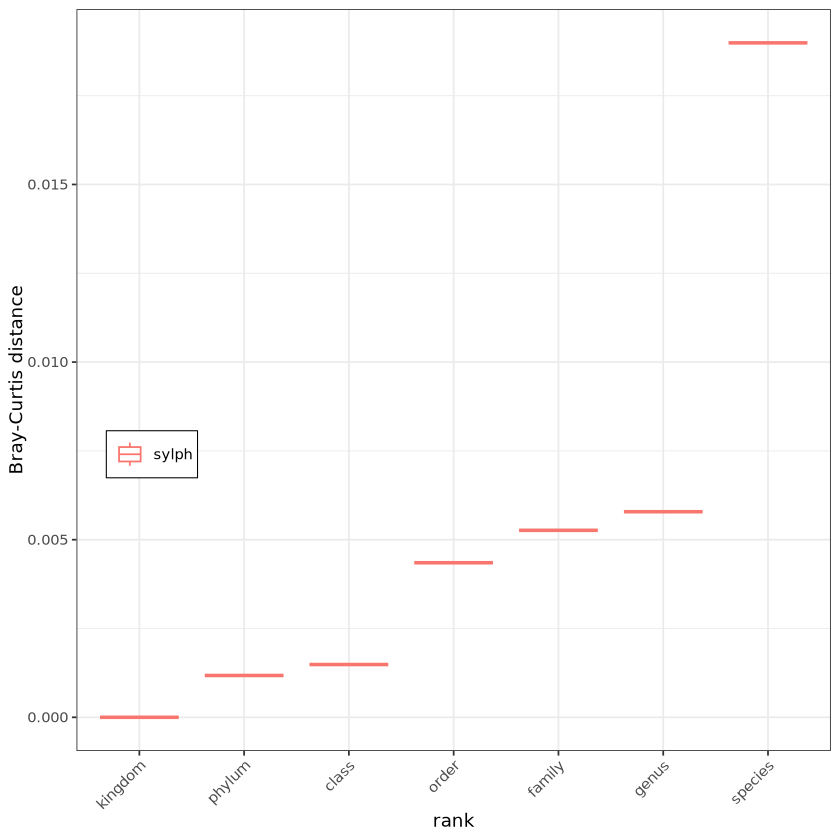

In [6]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`, colour = tool)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))

# Relationship between relative abundance and accuracy

In [10]:
truth_profiles = data.table(expand.grid(community=communities, dominance=dominance))
truth_profiles2 = truth_profiles[, fread(paste('truths/dominance', dominance, '/',community,'.condensed',sep='')), by=list(community, dominance)]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [11]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities, dominance = dominance))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/dominance',dominance, '/', community,'.profile',sep='')),
    by=list(tool,community,dominance)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, tool)]
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [13]:
# singlem and sylph relative abundances
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD, scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = ra_cols
    ][]
}

In [18]:
# singlem coverages
format_table_cov <- function(m) {
    cov_cols <- grep("^coverage_|_coverage$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^relabu_|_relabu$", names(m))), with = FALSE]
    mtmp[
        ,
        c(cov_cols, "taxonomy") := c(
            .SD,
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = cov_cols
    ][]
}

In [19]:
# kingdom
format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])
format_table_cov(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__sylph
<fct>,<chr>,<chr>,<chr>
sample4,d__Bacteria,100%,100%


community,taxonomy,true_coverage,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>
sample4,d__Bacteria,180,190.606


In [20]:
# phylum
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__sylph
<fct>,<chr>,<chr>,<chr>
sample4,d__Bacteria; p__Actinobacteriota,56.7%,56.6304%
sample4,d__Bacteria; p__Campylobacterota,1.7%,1.6253%
sample4,d__Bacteria; p__Cyanobacteria,1.7%,1.6631%
sample4,d__Bacteria; p__Desulfobacterota,3.3%,3.3645%
sample4,d__Bacteria; p__Firmicutes,6.7%,6.7044%
sample4,d__Bacteria; p__Firmicutes_A,5.0%,4.9993%
sample4,d__Bacteria; p__Firmicutes_C,1.7%,1.6495%
sample4,d__Bacteria; p__Proteobacteria,21.7%,21.7155%
sample4,d__Bacteria; p__Verrucomicrobiota,1.7%,1.6479%


community,taxonomy,true_coverage,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>
sample4,d__Bacteria; p__Actinobacteriota,102,107.941
sample4,d__Bacteria; p__Campylobacterota,3,3.098
sample4,d__Bacteria; p__Cyanobacteria,3,3.170
sample4,d__Bacteria; p__Desulfobacterota,6,6.413
sample4,d__Bacteria; p__Firmicutes,12,12.779
sample4,d__Bacteria; p__Firmicutes_A,9,9.529
sample4,d__Bacteria; p__Firmicutes_C,3,3.144
sample4,d__Bacteria; p__Proteobacteria,39,41.391
sample4,d__Bacteria; p__Verrucomicrobiota,3,3.141


In [21]:
# class
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__sylph
<fct>,<chr>,<chr>,<chr>
sample4,p__Actinobacteriota; c__Actinomycetia,56.7%,56.6304%
sample4,p__Campylobacterota; c__Campylobacteria,1.7%,1.6253%
sample4,p__Cyanobacteria; c__Cyanobacteriia,1.7%,1.6631%
sample4,p__Desulfobacterota; c__Desulfomonilia,1.7%,1.6789%
sample4,p__Desulfobacterota; c__Thermodesulfobacteria,1.7%,1.6857%
sample4,p__Firmicutes; c__Bacilli,6.7%,6.7044%
sample4,p__Firmicutes_A; c__Clostridia,5.0%,4.9993%
sample4,p__Firmicutes_C; c__Negativicutes,1.7%,1.6495%
sample4,p__Proteobacteria; c__Alphaproteobacteria,5.0%,5.0796%


community,taxonomy,true_coverage,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>
sample4,p__Actinobacteriota; c__Actinomycetia,102,107.941
sample4,p__Campylobacterota; c__Campylobacteria,3,3.098
sample4,p__Cyanobacteria; c__Cyanobacteriia,3,3.170
sample4,p__Desulfobacterota; c__Desulfomonilia,3,3.200
sample4,p__Desulfobacterota; c__Thermodesulfobacteria,3,3.213
sample4,p__Firmicutes; c__Bacilli,12,12.779
sample4,p__Firmicutes_A; c__Clostridia,9,9.529
sample4,p__Firmicutes_C; c__Negativicutes,3,3.144
sample4,p__Proteobacteria; c__Alphaproteobacteria,9,9.682


In [22]:
# order
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__sylph
<fct>,<chr>,<chr>,<chr>
sample4,c__Actinomycetia; o__Actinomycetales,6.7%,6.5103%
sample4,c__Actinomycetia; o__Streptomycetales,50.0%,50.1201%
sample4,c__Campylobacteria; o__Campylobacterales,1.7%,1.6253%
sample4,c__Cyanobacteriia; o__CAIUCS01,1.7%,1.6631%
sample4,c__Desulfomonilia; o__UBA1062,1.7%,1.6789%
sample4,c__Thermodesulfobacteria; o__Thermodesulfobacteriales,1.7%,1.6857%
sample4,c__Bacilli; o__Bacillales_A,1.7%,1.7245%
sample4,c__Bacilli; o__Lactobacillales,5.0%,4.9799%
sample4,c__Clostridia; o__Clostridiales,3.3%,3.3373%


community,taxonomy,true_coverage,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>
sample4,c__Actinomycetia; o__Actinomycetales,12,12.409
sample4,c__Actinomycetia; o__Streptomycetales,90,95.532
sample4,c__Campylobacteria; o__Campylobacterales,3,3.098
sample4,c__Cyanobacteriia; o__CAIUCS01,3,3.170
sample4,c__Desulfomonilia; o__UBA1062,3,3.200
sample4,c__Thermodesulfobacteria; o__Thermodesulfobacteriales,3,3.213
sample4,c__Bacilli; o__Bacillales_A,3,3.287
sample4,c__Bacilli; o__Lactobacillales,9,9.492
sample4,c__Clostridia; o__Clostridiales,6,6.361


In [23]:
# family
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__sylph
<fct>,<chr>,<chr>,<chr>
sample4,o__Actinomycetales; f__Bifidobacteriaceae,1.7%,1.62010%
sample4,o__Actinomycetales; f__Dermatophilaceae,1.7%,1.68568%
sample4,o__Actinomycetales; f__Microbacteriaceae,1.7%,1.64318%
sample4,o__Actinomycetales; f__Micrococcaceae,1.7%,1.56134%
sample4,o__Streptomycetales; f__Streptomycetaceae,50.0%,50.12014%
sample4,o__Campylobacterales; f__Helicobacteraceae,1.7%,1.62534%
sample4,o__CAIUCS01; f__CAIUCS01,1.7%,1.66312%
sample4,o__UBA1062; f__UBA1062,1.7%,1.67886%
sample4,o__Thermodesulfobacteriales; f__Thermodesulfobacteriaceae,1.7%,1.68568%


community,taxonomy,true_coverage,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>
sample4,o__Actinomycetales; f__Bifidobacteriaceae,3,3.088
sample4,o__Actinomycetales; f__Dermatophilaceae,3,3.213
sample4,o__Actinomycetales; f__Microbacteriaceae,3,3.132
sample4,o__Actinomycetales; f__Micrococcaceae,3,2.976
sample4,o__Streptomycetales; f__Streptomycetaceae,90,95.532
sample4,o__Campylobacterales; f__Helicobacteraceae,3,3.098
sample4,o__CAIUCS01; f__CAIUCS01,3,3.170
sample4,o__UBA1062; f__UBA1062,3,3.200
sample4,o__Thermodesulfobacteriales; f__Thermodesulfobacteriaceae,3,3.213


In [24]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__sylph
<fct>,<chr>,<chr>,<chr>
sample4,f__Bifidobacteriaceae; g__Bifidobacterium,1.7%,1.62010%
sample4,f__Dermatophilaceae; g__Marihabitans,1.7%,1.68568%
sample4,f__Microbacteriaceae; g__Leucobacter,1.7%,1.64318%
sample4,f__Micrococcaceae; g__Micrococcus,1.7%,1.56134%
sample4,f__Streptomycetaceae; g__Streptomyces,50.0%,50.12014%
sample4,f__Helicobacteraceae; g__Helicobacter_E,1.7%,1.62534%
sample4,f__CAIUCS01; g__CAIUCS01,1.7%,1.66312%
sample4,f__UBA1062; g__UBA1062,1.7%,1.67886%
sample4,f__Thermodesulfobacteriaceae; g__Thermodesulfobacterium,1.7%,1.68568%


community,taxonomy,true_coverage,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>
sample4,f__Bifidobacteriaceae; g__Bifidobacterium,3,3.088
sample4,f__Dermatophilaceae; g__Marihabitans,3,3.213
sample4,f__Microbacteriaceae; g__Leucobacter,3,3.132
sample4,f__Micrococcaceae; g__Micrococcus,3,2.976
sample4,f__Streptomycetaceae; g__Streptomyces,90,95.532
sample4,f__Helicobacteraceae; g__Helicobacter_E,3,3.098
sample4,f__CAIUCS01; g__CAIUCS01,3,3.170
sample4,f__UBA1062; g__UBA1062,3,3.200
sample4,f__Thermodesulfobacteriaceae; g__Thermodesulfobacterium,3,3.213


In [25]:
# Species level
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,true_relabu,relabu__sylph
<chr>,<fct>,<chr>,<chr>
g__Bifidobacterium; s__Bifidobacterium catenulatum,sample4,1.7%,1.62010%
g__Marihabitans; s__Marihabitans melonis,sample4,1.7%,1.68568%
g__Leucobacter; s__Leucobacter sp014529985,sample4,1.7%,1.64318%
g__Micrococcus; s__Micrococcus luteus,sample4,1.7%,1.56134%
g__Streptomyces; s__Streptomyces acidicola,sample4,1.7%,1.71453%
g__Streptomyces; s__Streptomyces albidoflavus,sample4,3.3%,3.04922%
g__Streptomyces; s__Streptomyces alfalfae,sample4,1.7%,1.73971%
g__Streptomyces; s__Streptomyces cinnamonensis,sample4,3.3%,2.69824%
g__Streptomyces; s__Streptomyces cyaneofuscatus,sample4,1.7%,1.66731%


taxonomy,community,true_coverage,coverage__sylph
<chr>,<fct>,<dbl>,<dbl>
g__Bifidobacterium; s__Bifidobacterium catenulatum,sample4,3,3.088
g__Marihabitans; s__Marihabitans melonis,sample4,3,3.213
g__Leucobacter; s__Leucobacter sp014529985,sample4,3,3.132
g__Micrococcus; s__Micrococcus luteus,sample4,3,2.976
g__Streptomyces; s__Streptomyces acidicola,sample4,3,3.268
g__Streptomyces; s__Streptomyces albidoflavus,sample4,6,5.812
g__Streptomyces; s__Streptomyces alfalfae,sample4,3,3.316
g__Streptomyces; s__Streptomyces cinnamonensis,sample4,6,5.143
g__Streptomyces; s__Streptomyces cyaneofuscatus,sample4,3,3.178
